# **Nearest Neighbour (NN) comparison between 3D and its 2D projection as a function of N (number of points).** 

- Generates N random points within a 3D sphere (radius R).
- Optionally rotates the cloud (Euler angles) before projection.
- Projects to 2D by dropping the z-axis.
- Computes NN in 3D and 2D.
- Compares edge sets and lengths; reports overlap metrics.
- Plots histograms of NN length ratios in 3D and 2D for different N.
- Plots 3D and 2D ratio as a function of N.
- Fits trend line to ratio vs. N in log-log space and reports slope.

Produces the following from Barnes et al. (2026): 

- **Fig 3 (bottom row)**: Nearest-neighbour (NN) comparisons for uniformly sampled point distributions. [...] Bottom: results from Monte Carlo ensembles (103 realisations each) for N = 5,
10, 20, and 50, showing stacked kernel density estimates of 3D (blue) and projected 2D (orange) NN edge lengths. The distributions converge a
stable median ratio as N increases, while stochastic fluctuations dominate at small N.


In [1]:
# Core scientific imports
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

# corespaceing3d imports
from corespaceing3d import main, run_main_mc
from corespaceing3d.plotting import rcParams

In [2]:
# ------------------------- configuration -------------------------
N_POINTS = 10      # number of points
RADIUS = 1.0         # sphere radius

# Rotation of the 3D clump *before* projecting to 2D
# (Right-handed, extrinsic rotations; order Z (alpha), Y (beta), X (gamma))
ALPHA_DEG = 0     # rotate about Z
BETA_DEG  = 0     # rotate about Y
GAMMA_DEG = 0     # rotate about X

# Toggle plotting
SHOW_PLOTS = True
# -----------------------------------------------------------------

=== Profile: uniform ===
N_POINTS = 5, RADIUS = 1.0
Total runs: 1000
Total edges: 3D=3454, 2D=3421
Global 3D mean edge length = 0.7025 ± 0.2744
Global 2D mean edge length = 0.4870 ± 0.2505
Run-level 3D mean = 0.6956 ± 0.1390
Run-level 2D mean = 0.4810 ± 0.1201
Run-level ratio (3D/2D) = 1.499 ± 0.347  [16–84%: 1.195–1.789]
Run-level ratio (2D/3D) = 0.696 ± 0.134  [16–84%: 0.559–0.837]
Median edge lengths: 3D=0.6846, 2D=0.4521
Percentile  5: 3D=0.2782, 2D=0.1324
Percentile 25: 3D=0.4957, 2D=0.2985
Percentile 50: 3D=0.6846, 2D=0.4521
Percentile 75: 3D=0.8945, 2D=0.6476
Percentile 95: 3D=1.1659, 2D=0.9445
Distribution overlap range fraction = 0.93
Kolmogorov–Smirnov test: D=0.323, p=2.939e-159
Coefficient of variation: 3D=0.391, 2D=0.514
Skewness: 3D=0.24, 2D=0.61
Kurtosis (excess): 3D=-0.41, 2D=-0.01

=== Profile: uniform ===
N_POINTS = 10, RADIUS = 1.0
Total runs: 1000
Total edges: 3D=7027, 2D=6922
Global 3D mean edge length = 0.5217 ± 0.2029
Global 2D mean edge length = 0.3233 ± 0.1735


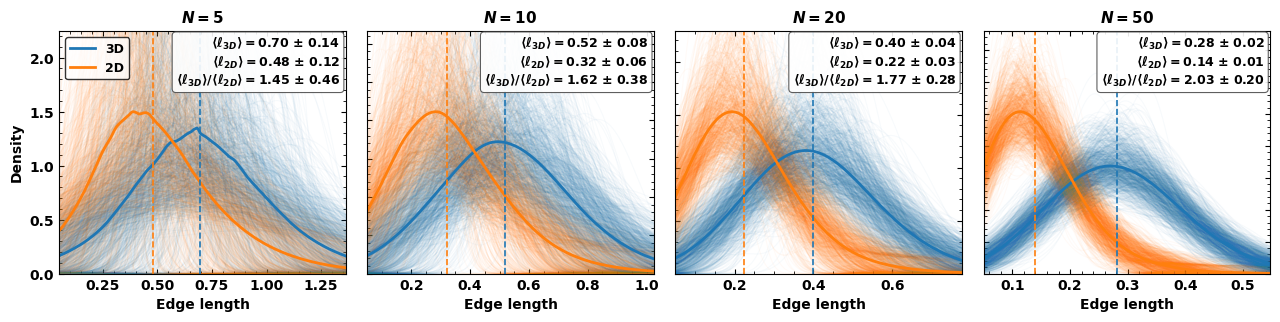

In [3]:
# --- configuration ---
N_values = [5, 10, 20, 50]
RADIUS = 1.0
ALPHA_DEG = 0.0
BETA_DEG  = 0.0
GAMMA_DEG = 0.0
BASE_SEED = 0
N_RUNS = 1000
profile = "uniform"
profile_kwargs = {}
colors = dict(threeD="tab:blue", twoD="tab:orange")

# run MC
out = []
for i, N in enumerate(N_values):

    out_ = run_main_mc(
        N_RUNS=N_RUNS,
        N=N,
        RADIUS=RADIUS,
        ALPHA_DEG=ALPHA_DEG,
        BETA_DEG=BETA_DEG,
        GAMMA_DEG=GAMMA_DEG,
        profile=profile,
        profile_kwargs=profile_kwargs,
        BASE_SEED=BASE_SEED,
        verbose=True
    )

    len3_runs, len2_runs, mu3_runs, mu2_runs, _ = out_
    out += [out_]

def _shared_grid(datasets, n=800, pad=0.05):
    data = np.concatenate([d for d in datasets if d.size])
    p1, p99 = np.percentile(data, [1, 99])
    lo, hi = float(p1), float(p99)
    span = hi - lo
    lo -= pad * span; hi += pad * span
    return np.linspace(max(lo, 0.0), hi, n)

def _kde_on_grid(samples, x):
    samples = np.asarray(samples)
    if samples.size < 2:
        return np.zeros_like(x)
    return gaussian_kde(samples)(x)

fig, axes = plt.subplots(1, len(N_values), figsize=(13, 3.5))
fig.subplots_adjust(wspace=0.15)

for i, N in enumerate(N_values):

    len3_runs, len2_runs, mu3_runs, mu2_runs, _ = out[i]

    xgrid = _shared_grid(len3_runs + len2_runs, n=900, pad=0.05)
    dens3_stack, dens2_stack = [], []
    ax = axes[i]

    for l3, l2 in zip(len3_runs, len2_runs):
        d3 = _kde_on_grid(l3, xgrid)
        d2 = _kde_on_grid(l2, xgrid)
        ax.plot(xgrid, d3, color=colors["threeD"], alpha=0.03, lw=0.8)
        ax.plot(xgrid, d2, color=colors["twoD"],  alpha=0.03, lw=0.8)
        dens3_stack.append(d3)
        dens2_stack.append(d2)
    dens3_stack = np.vstack(dens3_stack)
    dens2_stack = np.vstack(dens2_stack)
    mean3 = dens3_stack.mean(axis=0)
    mean2 = dens2_stack.mean(axis=0)
    ax.plot(xgrid, mean3, color=colors["threeD"], lw=2.0, label="3D")
    ax.plot(xgrid, mean2, color=colors["twoD"],  lw=2.0, label="2D")

    mu3, s3 = np.nanmean(mu3_runs), np.nanstd(mu3_runs, ddof=1)
    mu2, s2 = np.nanmean(mu2_runs), np.nanstd(mu2_runs, ddof=1)
    R = mu3 / mu2
    sR = R * np.sqrt((s3/mu3)**2 + (s2/mu2)**2)
    ax.axvline(mu3, color=colors["threeD"], ls="--", lw=1.2)
    ax.axvline(mu2, color=colors["twoD"],  ls="--", lw=1.2)

    txt = (
        # f"$N={N}$\n"
        r"$\langle \ell_{3D}\rangle = $" + f"{mu3:.2f} ± {s3:.2f}\n"
        r"$\langle \ell_{2D}\rangle = $" + f"{mu2:.2f} ± {s2:.2f}\n"
        r"$\langle \ell_{3D}\rangle/\langle \ell_{2D}\rangle = $" + f"{R:.2f} ± {sR:.2f}"
    )
    ax.text(
        0.98, 0.98, txt, transform=ax.transAxes, ha="right", va="top",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.3", lw=0.8, alpha=0.9)
    )
    ax.set_title(f"$N = {N}$", fontsize=11)
    ax.set_xlabel("Edge length")
    if i == 0:
        ax.set_ylabel("Density")
        leg = ax.legend(frameon=True, fontsize=9, loc="upper left")
        leg.get_frame().set_edgecolor("black")
    # ax.grid(True, alpha=0.3)
    # ax.set_xlim(0.0, xgrid.max())
    # ax.set_ylim(0, 1.5 * max(mean3.max(), mean2.max()))

    # Set reasonable x/y limits
    ax.set_xlim(0.05, xgrid.max())
    ax.set_ylim(0, 1.5 * max(mean3.max(), mean2.max()))

for ax in axes[1:]:
    ax.tick_params(labelleft=False)

# fig.suptitle("Uniform distribution — Monte Carlo KDEs for 3D vs 2D NN edge lengths", fontsize=12)
fig.tight_layout(rect=[0, 0, 1, 0.95])

fig.savefig(
    "./../figures/kde_stacks_uniform_N5_10_20_50.pdf",
    dpi=300, bbox_inches="tight"
)
plt.show()

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ratio_vs_N(
    N_values,
    runs=50,
    profile="uniform",
    profile_kwargs=None,
    RADIUS=1.0,
    ALPHA_DEG=0.0,
    BETA_DEG=0.0,
    GAMMA_DEG=0.0,
    BASE_SEED=0,
    show_points=True,
    ax=None,
    label=None,
    color="tab:purple",
    savepath=None,
    alpha=1.0,
):
    """
    For each N in N_values, run the pipeline 'runs' times and compute
    C = mean(len3) / mean(len2). Plot the mean C(N) and ±1σ band.

    Parameters
    ----------
    N_values : array-like
        List/array of N (number of points) to test.
    runs : int
        Number of realizations per N.
    profile : str
        'uniform' | 'gaussian' | 'powerlaw' | 'plummer' | 'exponential' | 'shell'
    profile_kwargs : dict or None
        Parameters for the chosen profile (e.g. {'sigma':0.25}, {'p':-2}, {'a':0.25}).
    RADIUS, ALPHA_DEG, BETA_DEG, GAMMA_DEG : float
        Geometry settings passed to main().
    BASE_SEED : int
        Base seed; per-run seeds are BASE_SEED + k.
    show_points : bool
        If True, plot faint per-run ratios as scatter.
    ax : matplotlib.axes.Axes or None
        Axis to draw on. If None, a new fig/ax is created.
    label : str or None
        Label for the mean curve (useful if overlaying multiple profiles).
    color : str
        Matplotlib color for the mean line and band.
    savepath : str or None
        If given, save the figure to this path.

    Returns
    -------
    result : dict
        {
          'N_values': np.ndarray,
          'ratios': list of np.ndarray (per-run ratios for each N),
          'mean': np.ndarray,
          'std': np.ndarray
        }
    """
    if profile_kwargs is None:
        profile_kwargs = {}

    N_values = np.asarray(N_values, dtype=int)
    ratios_per_N = []
    means = []
    stds = []

    for i, N in enumerate(N_values):
        r_list = []
        for k in range(runs):
            out = main(
                N_POINTS=N,
                RADIUS=RADIUS,
                SEED=BASE_SEED + k,
                profile=profile,
                profile_kwargs=profile_kwargs,
                ALPHA_DEG=ALPHA_DEG,
                BETA_DEG=BETA_DEG,
                GAMMA_DEG=GAMMA_DEG,
                verbose=False,
            )
            len3 = np.asarray(out["len3"], dtype=float)
            len2 = np.asarray(out["len2"], dtype=float)
            # Per-run ratio: mean 3D edge length divided by mean 2D edge length
            m3 = len3.mean() if len3.size else np.nan
            m2 = len2.mean() if len2.size else np.nan
            r = m3 / m2 if (np.isfinite(m3) and np.isfinite(m2) and m2 > 0) else np.nan
            r_list.append(r)

        r_arr = np.array(r_list, dtype=float)
        ratios_per_N.append(r_arr)
        means.append(np.nanmean(r_arr))
        stds.append(np.nanstd(r_arr, ddof=1))

    means = np.array(means, dtype=float)
    stds = np.array(stds, dtype=float)

    # ---- Plot ----
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6.5, 4.0))
        created_fig = True

    # Optional scatter of all per-run points (faint)
    if show_points:
        for N, r_arr in zip(N_values, ratios_per_N):
            x = np.full_like(r_arr, N, dtype=float)
            ax.scatter(x, r_arr, s=10, alpha=0.15, color=color, zorder=1)

    # Mean curve and ±1σ band
    lbl = label if label else f"{profile}"
    # Compose a pretty label with params
    if label is None and profile_kwargs:
        if profile == "gaussian" and "sigma" in profile_kwargs:
            lbl += rf" ($\sigma={profile_kwargs['sigma']}$)"
        elif profile == "powerlaw" and "p" in profile_kwargs:
            lbl += rf" ($p={profile_kwargs['p']}$)"
        elif profile == "plummer" and "a" in profile_kwargs:
            lbl += rf" ($a={profile_kwargs['a']}$)"
        elif profile == "exponential" and "r0" in profile_kwargs:
            lbl += rf" ($r_0={profile_kwargs['r0']}$)"
        elif profile == "shell" and "r0" in profile_kwargs:
            lbl += rf" ($r_0={profile_kwargs['r0']}$)"
        elif profile == "fractal" and "D" in profile_kwargs:
            lbl += rf" ($D={profile_kwargs['D']}$, n$_\mathrm{{div}}$={profile_kwargs.get('n_div',2)})"

    ax.plot(N_values, means, color=color, lw=2.2, label=lbl, zorder=3, alpha=alpha)
    ax.fill_between(N_values, means - stds, means + stds, color=color, alpha=0.10, zorder=2)
    ax.plot(N_values, means - stds, color=color, lw=1.0, ls='--', zorder=2, alpha=alpha)
    ax.plot(N_values, means + stds, color=color, lw=1.0, ls='--', zorder=2, alpha=alpha)

    ax.set_xlabel("Number of points $N$")
    # ax.set_ylabel(r"$\,\overline{\ell}_{\rm 3D}/\overline{\ell}_{\rm 2D}\,$")
    ax.set_ylabel(r"$\langle \ell_{\rm 3D} \rangle/ \langle \ell_{\rm 2D} \rangle$")
    # ax.grid(True, alpha=0.3)
    # ax.legend(frameon=True, fontsize=9)

    # Reasonable limits: start at 0 on y, a little headroom on top
    ymin = max(0.0, np.nanmin(means - stds))
    ymax = np.nanmax(means + stds)
    ax.set_ylim(0.0, 1.1 * ymax if np.isfinite(ymax) else 1.0)

    # If N spans a big range, you may want log-x:
    # ax.set_xscale("log"); ax.set_xticks(N_values); ax.get_xaxis().set_major_formatter(matplotlib.ticker.ScalarFormatter())

    if created_fig:
        plt.tight_layout()
        if savepath:
            plt.savefig(savepath, dpi=300, bbox_inches="tight")

    return {
        "N_values": N_values,
        "ratios": ratios_per_N,
        "mean": means,
        "std": stds,
    }

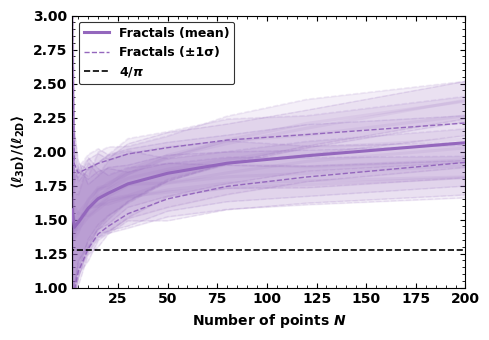

In [5]:
jitter = True  # add small Gaussian jitter to break grid regularity
prune = True   # prune to sphere before scaling (approx. spherical cluster)

N_values = [2, 3, 5, 10, 15, 20, 30, 50, 80, 120, 200]
runs = 100

fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
# out_uniform = plot_ratio_vs_N(N_values, runs=runs, profile="uniform",  color="grey",  ax=ax, show_points=False, alpha=0.3)

out_fractals = []

Ds = [1.7, 2.0, 2.5]
n_divs = [2, 3, 4]
for D in Ds:
    for n_div in n_divs:
        profile_kwargs = {'D':D, 'n_div':n_div, 'jitter':jitter, 'prune':prune}
        out_fractal = plot_ratio_vs_N(N_values, runs=runs, profile="fractal", profile_kwargs=profile_kwargs, color="C4",  ax=ax, show_points=False, alpha=0.1)
        out_fractals += [out_fractal]

mean_fractal = np.mean([of['mean'] for of in out_fractals], axis=0)
std_fractal = np.mean([of['std'] for of in out_fractals], axis=0)
out_fractals_mean = {'N_values': N_values, 'mean': mean_fractal, 'std': std_fractal}

ax.plot(N_values, mean_fractal, color="C4", lw=2.2, label="Fractals", zorder=3, alpha=1.0)
ax.plot(N_values, mean_fractal - std_fractal, color="C4", lw=1.0, ls='--', zorder=2, alpha=1.0)
ax.plot(N_values, mean_fractal + std_fractal, color="C4", lw=1.0, ls='--', zorder=2, alpha=1.0)

ax.set_xlim(N_values[0], N_values[-1])
ax.set_ylim(1, 3)

ax.plot([0,500], [4/np.pi]*2, 'k--', lw=1.2, label=r"$4/\pi$")

# --- custom legend (proxy artists) ---
leg_mean  = Line2D([], [], color="C4", lw=2.2, label="Fractals (mean)")
leg_pm1   = Line2D([], [], color="C4", lw=1.0, ls="--", label="Fractals (±1σ)")
leg_geom  = Line2D([], [], color="k",  lw=1.2, ls="--", label=r"$4/\pi$")

leg = ax.legend(handles=[leg_mean, leg_pm1, leg_geom],
                loc="upper left", frameon=True, fontsize=9)

# optional: tweak the legend frame
leg.get_frame().set_facecolor("white")
leg.get_frame().set_edgecolor("black")
leg.get_frame().set_linewidth(0.8)

fig.tight_layout()
fig.savefig("./../figures/ratio_vs_N_all_fractal_profiles.pdf", dpi=300, bbox_inches="tight")

In [6]:
def print_ratio_summary(name, out):
    """
    Print summary of ratio results vs N for one profile.
    """
    Nvals = out["N_values"]
    means = out["mean"]
    stds  = out["std"]

    print(f"=== Profile: {name} ===")
    for N, m, s in zip(Nvals, means, stds):
        print(f"N={N:4d}:  mean ratio (3D/2D) = {m:.3f} ± {s:.3f}")
    print(f"Overall mean across N: {means.mean():.3f} ± {means.std(ddof=1):.3f}")
    print()

for i, out_fractal in enumerate(out_fractals):
    print("Params: D = {}, n_div = {}".format(Ds[i//3], n_divs[i%3]))
    print_ratio_summary("Fractal", out_fractal)

Params: D = 1.7, n_div = 2
=== Profile: Fractal ===
N=   2:  mean ratio (3D/2D) = 1.656 ± 1.316
N=   3:  mean ratio (3D/2D) = 1.590 ± 0.576
N=   5:  mean ratio (3D/2D) = 1.544 ± 0.393
N=  10:  mean ratio (3D/2D) = 1.529 ± 0.228
N=  15:  mean ratio (3D/2D) = 1.595 ± 0.224
N=  20:  mean ratio (3D/2D) = 1.649 ± 0.234
N=  30:  mean ratio (3D/2D) = 1.676 ± 0.224
N=  50:  mean ratio (3D/2D) = 1.767 ± 0.207
N=  80:  mean ratio (3D/2D) = 1.814 ± 0.183
N= 120:  mean ratio (3D/2D) = 1.839 ± 0.170
N= 200:  mean ratio (3D/2D) = 1.896 ± 0.150
Overall mean across N: 1.687 ± 0.125

Params: D = 1.7, n_div = 3
=== Profile: Fractal ===
N=   2:  mean ratio (3D/2D) = 1.583 ± 1.180
N=   3:  mean ratio (3D/2D) = 1.492 ± 0.649
N=   5:  mean ratio (3D/2D) = 1.480 ± 0.376
N=  10:  mean ratio (3D/2D) = 1.577 ± 0.378
N=  15:  mean ratio (3D/2D) = 1.613 ± 0.262
N=  20:  mean ratio (3D/2D) = 1.614 ± 0.213
N=  30:  mean ratio (3D/2D) = 1.661 ± 0.223
N=  50:  mean ratio (3D/2D) = 1.717 ± 0.196
N=  80:  mean ratio (3

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def fit_loglog(out_profile, color="C1", label=r"Gaussian",
                           seed=123, show=True):
    """
    Fit a log–log relation C(N) = mean(l3D)/mean(l2D) with linmix:
        log10 C = alpha + beta * log10 N
    Includes intrinsic scatter. Falls back to weighted LS if linmix not installed.

    Parameters
    ----------
    out_gaussian : dict
        Output from plot_ratio_vs_N for the Gaussian profile.
    color : str
        Plot color for line/band.
    label : str
        Legend label for the fitted relation.
    seed : int
        Random seed for linmix MCMC.
    savepath : str or None
        If provided, save the figure to this path.
    show : bool
        If True, show the plot.

    Returns
    -------
    result : dict with keys
        'alpha_med','alpha_lo','alpha_hi',
        'beta_med','beta_lo','beta_hi',
        'sigma_int_med','sigma_int_lo','sigma_int_hi',
        'fallback' (bool),
        'x','y','yerr'
    """
    N = np.asarray(out_profile["N_values"], dtype=float)
    Cmean = np.asarray(out_profile["mean"], dtype=float)
    Cstd  = np.asarray(out_profile["std"],  dtype=float)

    # Build log10 data; propagate errors: sigma_y = sigma_C / (C * ln 10)
    x = np.log10(N)
    y = np.log10(Cmean)
    # avoid division by zero
    yerr = np.where((Cmean > 0) & np.isfinite(Cstd), Cstd / (Cmean * np.log(10.0)), np.nan)

    # Mask finite points
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    xfit, yfit, ysig = x[m], y[m], yerr[m]
    xsig = np.zeros_like(xfit)  # N has no uncertainty here

    # ---- Fallback: weighted least squares in log–log ----
    # weights = 1/sigma_y^2
    w = 1.0 / np.maximum(ysig**2, 1e-12)
    # polyfit with weights in log space
    coeffs = np.polyfit(xfit, yfit, 1, w=w)
    beta_med = coeffs[0]
    alpha_med = coeffs[1]
    # crude uncertainties via covariance of linear regression
    # build design matrix
    X = np.vstack([xfit, np.ones_like(xfit)]).T
    W = np.diag(w)
    XtWX = X.T @ W @ X
    cov = np.linalg.inv(XtWX)
    beta_err = np.sqrt(cov[0,0])
    alpha_err = np.sqrt(cov[1,1])

    # Band: use ±1σ on parameters
    xfine = np.linspace(xfit.min()*0.98, xfit.max()*1.02, 400)
    y_med = alpha_med + beta_med * xfine
    y_lo  = (alpha_med - alpha_err) + (beta_med - beta_err) * xfine
    y_hi  = (alpha_med + alpha_err) + (beta_med + beta_err) * xfine

    fig, ax = plt.subplots(1, 1, figsize=(5, 3.5))
    ax.errorbar(N[m], Cmean[m], yerr=Cstd[m], fmt='o', ms=4, lw=1,
                color=color, alpha=0.9, label=label)
    Nfine = 10**xfine

    label_fit = "Fit: " + r"$\langle \ell_{\rm 3D} \rangle/ \langle \ell_{\rm 2D} \rangle \propto N^{%0.2f}$" %(beta_med)

    ax.plot(Nfine, 10**y_med, color=color, lw=2.5, label=label_fit)
    ax.fill_between(Nfine, 10**y_lo, 10**y_hi, color=color, alpha=0.15, lw=0)
    ax.plot(Nfine, 10**y_lo, color=color, lw=1.0, ls='--')
    ax.plot(Nfine, 10**y_hi, color=color, lw=1.0, ls='--')
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel("Number of points $N$")
    # ax.set_ylabel(r"$\overline{\ell}_{\rm 3D}/\overline{\ell}_{\rm 2D}$")
    ax.set_ylabel(r"$\langle \ell_{\rm 3D} \rangle/ \langle \ell_{\rm 2D} \rangle$")
    # ax.grid(True, which='both', alpha=0.3)

    ax.set_xlim(0, 300)
    plt.tight_layout()

    A0 = 10**alpha_med
    print("\n=== log–log fit (fallback: weighted LS) ===")
    print("Model: log10 C = alpha + beta * log10 N   (C = 10^alpha * N^beta)")
    print(f"alpha  = {alpha_med:.4f} ± {alpha_err:.4f}")
    print(f"beta   = {beta_med:.4f} ± {beta_err:.4f}")
    print(f"A0=10^alpha = {A0:.3f}")
    print("===========================================\n")

    return fig, ax, dict(alpha_med=alpha_med, alpha_lo=np.nan, alpha_hi=np.nan,
                beta_med=beta_med,  beta_lo=np.nan,  beta_hi=np.nan,
                sigma_int_med=np.nan, sigma_int_lo=np.nan, sigma_int_hi=np.nan,
                fallback=True, x=xfit, y=yfit, yerr=ysig)


=== log–log fit (fallback: weighted LS) ===
Model: log10 C = alpha + beta * log10 N   (C = 10^alpha * N^beta)
alpha  = 0.1190 ± 0.0651
beta   = 0.0851 ± 0.0345
A0=10^alpha = 1.315



/var/folders/3y/cmsgt3_x7x72bbs__zhy_q6h0008wr/T/ipykernel_57308/417010245.py:89: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, 300)


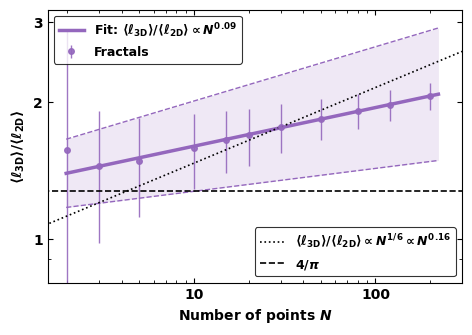

In [8]:
fig, ax, fitres = fit_loglog(
    out_fractals_mean,
    color="C4",
    label=r"Fractals",
    seed=123,
    show=True
    )

x = np.linspace(1, 300, 50)

# Data legend (whatever you already have)
leg_data = ax.legend(frameon=True, fontsize=9, loc="upper left")
ax.add_artist(leg_data)  # keep it around
leg_data.get_frame().set_edgecolor('black')
leg_data.get_frame().set_linewidth(0.8)

# Reference lines
ref_handles = [
    ax.plot([], [], 'k:', lw=1.2,
            label=r"$\langle \ell_{\rm 3D} \rangle/ \langle \ell_{\rm 2D} \rangle \propto N^{1/6} \propto N^{0.16}$")[0],
    ax.plot([], [], 'k--', lw=1.2, label=r"$4/\pi$")[0],
]
leg_refs = ax.legend(handles=ref_handles, frameon=True, fontsize=9, loc="lower right")
leg_refs.get_frame().set_edgecolor('black')
leg_refs.get_frame().set_linewidth(0.8)

ax.plot(x, x**(1/6), 'k:', lw=1.2)
ax.plot([0,500], [4/np.pi]*2, 'k--', lw=1.2)
ax.set_ylim(0.8, 3.2)

import matplotlib.ticker as mticker

formatter = mticker.ScalarFormatter()
formatter.set_scientific(False)
formatter.set_useOffset(False)

ax.xaxis.set_major_locator(mticker.LogLocator(base=10))
ax.xaxis.set_major_formatter(formatter)

ax.yaxis.set_major_locator(mticker.FixedLocator([1, 2, 3]))
ax.yaxis.set_major_formatter(formatter)

# minor_locator = mticker.LogLocator(base=10, subs=np.arange(0, 3, 0.1), numticks=10)
# ax.yaxis.set_minor_locator(minor_locator)
ax.yaxis.set_minor_formatter(mticker.NullFormatter())

fig.savefig("./../figures/loglog_C_vs_N_fractal_linmix.pdf", dpi=300, bbox_inches="tight")